# 1. Chargement et aperçu du dataset

In [1]:
import pandas as pd
df = pd.read_csv('insurance-data.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# 2. EDA (Analyse Exploratoire)

## 2.1 Structure, types, valeurs manquantes et doublons

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
# Statistiques descriptives
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [4]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
# Identifier la ligne en doublon
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,expenses
581,19,male,30.6,0,no,northwest,1639.56


In [7]:
# supprimer la ligne 
df = df.drop_duplicates()
df.duplicated().sum()
print(df.shape)

(1337, 7)


## 2.2 Distributions (histogrammes)

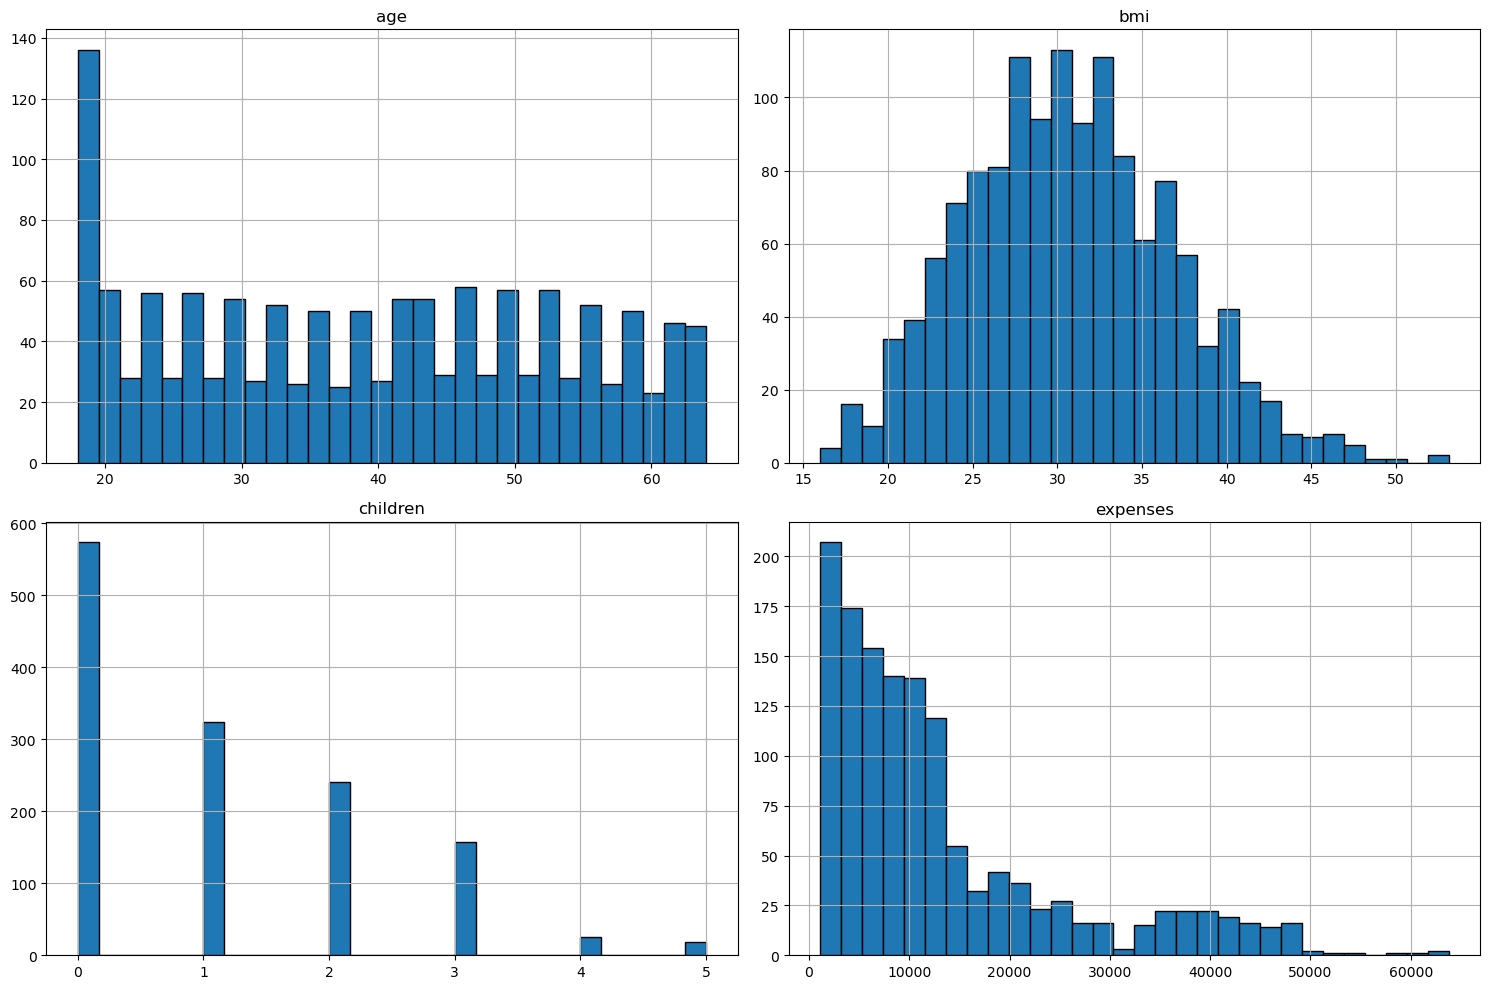

In [8]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

### Commentaire :
- Les distributions des variables numériques présentent des profils variés. L'âge est réparti de façon relativement homogène entre 18 et 64 ans, avec un pic net autour de 18 et 19 ans.
- la majorité des assurés n'a aucun enfant.
- La distribution de l'IMC (bmi) est relativement symétrique.
- Les frais médicaux (expenses) est la variable cible, présentent à l'inverse une distribution très asymétrique à droite.

## 2.3 Tendances métiers : surcoût tabagisme et IMC 

###  impact du tabagisme sur les frais

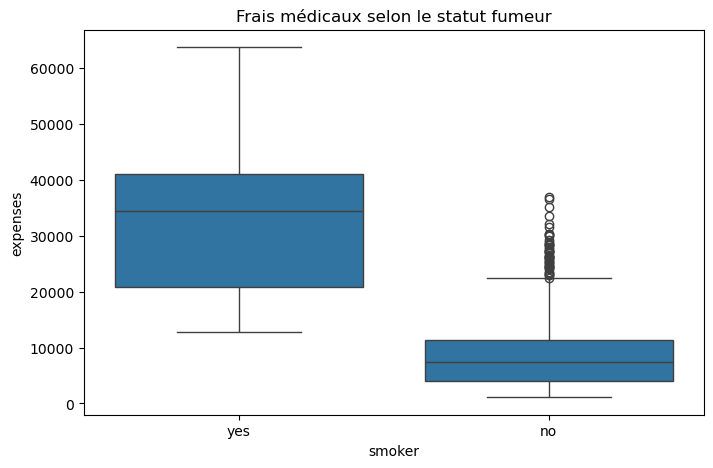

smoker
no      8440.660461
yes    32050.231971
Name: expenses, dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Frais médicaux selon le statut fumeur")
plt.show()

df.groupby('smoker')['expenses'].mean()

### Commentaire :
Le statut fumeur a un impact considérable sur les frais médicaux. Les deux sous-populations (fumeurs et non-fumeurs) ont des profils de coûts suffisamment distincts. Le tabagisme apparaît ainsi comme un facteur de risque majeur, cohérent avec les connaissances médicales générales sur les effets du tabac sur la santé.

In [10]:
# Quartiles, IQR et fences par statut fumeur (valeurs affichées au survol du boxplot dans l'app streamlit)
for statut, groupe in df.groupby('smoker')['expenses']:
    q1 = groupe.quantile(0.25)
    q3 = groupe.quantile(0.75)
    iqr = q3 - q1
    limite_haute = q3 + 1.5 * iqr
    limite_basse = q1 - 1.5 * iqr
    upper_fence = groupe[groupe <= limite_haute].max()
    lower_fence = groupe[groupe >= limite_basse].min()
    nb_outliers = (groupe > limite_haute).sum()
    print(f"{statut} : Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}  "
          f"lower fence={lower_fence:.0f}  upper fence={upper_fence:.0f}  outliers={nb_outliers}")

no : Q1=3989  Q3=11363  IQR=7374  lower fence=1122  upper fence=22396  outliers=46
yes : Q1=20826  Q3=41019  IQR=20193  lower fence=12829  upper fence=63770  outliers=0


### Commentaire
- Les fences sont les limites au-delà desquelles une valeur est considérée comme atypique : Q3 + 1,5 × IQR en haut, Q1 − 1,5 × IQR en bas.
- Non-fumeurs : 46 clients dépassent l'upper fence (22 396). Ce sont les points isolés au-dessus de la boîte.
- Fumeurs : aucun client ne dépasse la limite haute, donc l'upper fence correspond au client le plus cher (63 770).

### Lien IMC (bmi) et frais

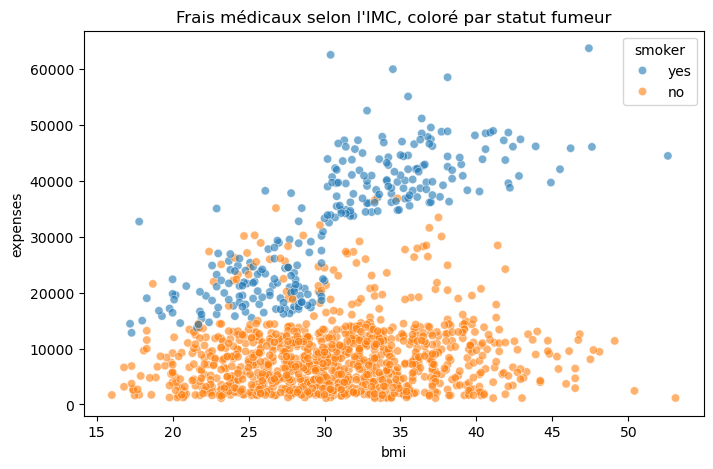

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='expenses', hue='smoker', data=df, alpha=0.6)
plt.title("Frais médicaux selon l'IMC, coloré par statut fumeur")
plt.show()

### Commentaire : Ce graphique révèle une relation claire entre l'IMC, le statut fumeur et les frais médicaux.
- Chez les non-fumeurs (points orange), les frais restent globalement bas et relativement stables quel que soit l'IMC.
- Chez les fumeurs (points bleus), on distingue nettement deux groupes : ceux avec un IMC inférieur et d'autres supérieures. 


## 2.4 Corrélations

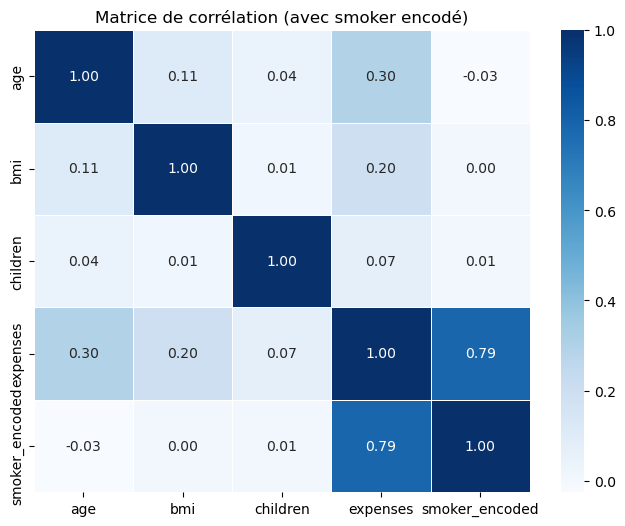

In [12]:
# On travaille sur une COPIE du DataFrame, 
# pour ne pas modifier df original.
# Une bonne pratique générale de programmation pour éviter de créer des colonnes redondantes
# (l'encodage ici est temporaire, juste pour visualiser la corrélation)
df_corr = df.copy()
# On crée une nouvelle colonne 'smoker_encoded' :
df_corr['smoker_encoded'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
corr_matrix = df_corr.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title("Matrice de corrélation (avec smoker encodé)")
plt.show()

### Commentaire :
On constate une forte correlation entre les fumeurs et les frais médicaux (0.79).
L'IMC a une corrélation faible avec les frais médicaux (0.20).
Le nombre d'enfants n'a presque aucune correlation avec les frais médicaux.

# 3. Prétraitement

## 3.1 Encodage (sex, smoker, region)

### Commentaire 
Les variables catégorielles sex et smoker ont été encodées en valeurs binaires (0/1), et region a été transformée via One-Hot Encoding en 3 colonnes indicatrices (northwest, southeast, southwest), la catégorie northeast servant de référence implicite. Toutes les variables sont désormais numériques, prêtes pour la standardisation et la modélisation.

In [13]:
# On recharge le fichier depuis le CSV d'origine pour repartir de données propres :
# sex/smoker contenaient encore du texte ("male"/"female", "yes"/"no") à ce stade,
# et une exécution précédente de cette cellule avait déjà transformé ces colonnes
# en 0/1, ce qui provoquait des NaN en relançant .map() une seconde fois sur des
# valeurs déjà numériques
# df = pd.read_csv('insurance-data.csv')
# df = df.drop_duplicates()
df_copie = df.copy()


# One-Hot encoding pour région (4 catégories, sans ordre) et sex/smoker qui sont binaire
df= pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)
df.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


## 3.2 Split train et test

In [14]:
# Séparer features (X) et target (y)
X = df.drop(columns='expenses')
Y = df['expenses']

print(X.columns.tolist())
print(X.shape, Y.shape)

['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
(1337, 8) (1337,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1069, 8) (268, 8)


## 3.3 Standardisation

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraînement de plusieurs modèles et comparaison (Régression Linéaire et Random Forest) (Zohair)

## 4.1 Régression Linéaire (Zohair)

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)
Y_pred_lr = lr.predict(X_test_scaled)

## 4.2 Random Forest (Zohair)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, Y_train)
Y_pred_rf = rf.predict(X_test_scaled)

## 4.3 Métriques pour les deux modèles (Régression linèaire et Random Forest) (Zohair)

In [19]:
from sklearn import metrics

for nom, Y_pred in [('Régression Linéaire', Y_pred_lr), ('Random Forest', Y_pred_rf)]:
    mae = metrics.mean_absolute_error(Y_test, Y_pred)
    mse = metrics.mean_squared_error(Y_test, Y_pred)
    r2 = metrics.r2_score(Y_test, Y_pred)
    print(f"{nom} - MAE: {mae: .2f}, MSE: {mse:.2f}, R2: {r2:.3f}")

Régression Linéaire - MAE:  4177.27, MSE: 35481471.60, R2: 0.807
Random Forest - MAE:  2664.86, MSE: 22227850.25, R2: 0.879


### Commentaire 
- MAE : Random Forest se trompe en moyenne de 2665, contre 4177 pour la Régression Linéaire.
- MSE : plus faible pour Random Forest.
- R2 : Random Forest explique presque 88% de la variance des frais médicaux, contre presque 80% pour la Régression Linéaire.
- **Conclusion** : Random Forest est nettement plus performant que la Régression Linéaire sur les trois métriques (MAE, MSE, R²).

## 4.4 Analyse des erreurs sur les deux modèles (Zohair)

In [20]:
# Comparaison 

comparaison = pd.DataFrame({
    'Réel': Y_test.values,
    'Régression Linéaire' : Y_pred_lr,
    'Random Forest': Y_pred_rf
})
comparaison['Erreur_LR']= abs(comparaison['Réel'] - comparaison['Régression Linéaire'])
comparaison['Erreur_RF']= abs(comparaison['Réel'] - comparaison['Random Forest'])
comparaison.sort_values('Erreur_RF', ascending=False).head(10)

,Réel,Régression Linéaire,Random Forest,Erreur_LR,Erreur_RF
124,28340.19,9013.009831,8075.4945,19327.180169,20264.6955
14,24915.05,10805.388539,6284.8731,14109.661461,18630.1769
79,30260.00,12811.475269,12670.8087,17448.524731,17589.1913
24,55135.40,31098.113614,38505.7521,24037.286386,16629.6479
34,63770.43,39657.187160,47521.5808,24113.242840,16248.8492
175,32734.19,26271.368830,16975.5809,6462.821170,15758.6091
197,20177.67,5028.632106,4715.3791,15149.037894,15462.2909
254,60021.40,36992.896135,44640.1873,23028.503865,15381.2127
190,17878.90,8277.493465,2993.3769,9601.406535,14885.5231
242,20277.81,5970.187039,5399.2639,14307.622961,14878.5461


### Commenatire
Random Forest est globalement meilleur sur l'ensemble du jeu de test, bien que plus performant en moyenne, il n'est pas systématiquement meilleur sur tous les cas individuels, spécifiquement sur les valeurs extrêmes où la Régression Linéaire garde parfois l'avantage.

# 5. Réglage des hyperparamètres (Zohair)

In [21]:
# GridSearchCV : meilleurs paramètres trouvés
from sklearn.model_selection import GridSearchCV # teste automatiquement plusieurs combinaisons 
# de paramètres pour trouver celle qui donne la meilleure performance

param_grid = {
    'n_estimators' : [100, 200, 300], # (nombre d'arbres dans la forêt) : essayer 100, 200 ou 300
    'max_depth' : [None, 5, 10, 15] # max_depth (profondeur maximale de chaque arbre) : essayer sans limite (None), 
                                    # ou limiter à 5, 10 ou 15
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, Y_train)

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score R2 (CV) :", grid_search.best_score_)

Meilleurs paramètres: {'max_depth': 5, 'n_estimators': 200}
Meilleur score R2 (CV) : 0.8427065867713178


### Commentaire 
Le réglage des hyperparamètres via GridSearchCV révèle que la meilleure combinaison est max_depth=5 et n_estimators=200, avec un score R² de presque 0.84. la profondeur optimale (5) est nettement inférieure à la profondeur par défaut illimitée (None) utilisée initialement, cela suggère qu'un Random Forest plus simple, avec des arbres moins profonds, généralise mieux sur ce dataset et limite le risque de surapprentissage. Ce résultat confirme l'intérêt du réglage des hyperparamètres pour affiner la performance du modèle au-delà des paramètres par défaut.

In [22]:
# Entraîner rf_optimise avec ces paramètres et vérifier son R² sur X_test

rf_optimise = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_optimise.fit(X_train_scaled, Y_train)
y_pred_rf_optimise = rf_optimise.predict(X_test_scaled)

r2_optimise = metrics.r2_score(Y_test, y_pred_rf_optimise)
print("R² Random Forest optimisé (sur X_test) :", r2_optimise)
print("R² Random Forest initial (sur X_test)   :", metrics.r2_score(Y_test, Y_pred_rf))

R² Random Forest optimisé (sur X_test) : 0.9012932885075025
R² Random Forest initial (sur X_test)   : 0.8790361024315173


### Commentaire 
Le réglage des hyperparamètres a bien amélioré mon modèle. Random Forest optimisé devient donc le meilleur modèle identifié à ce stade en attendant de croiser mes résultat avec celui de mon binôme. 

# 6. Entraînement de plusieurs modèles et comparaison (KNN + Arbre de Décision) (Brice)


## 6.1 Imports et préparation des données


In [23]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 6.2 Modèle K-Nearest Neighbors (KNN) - Entraînement et Évaluation


In [24]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, Y_train)
y_pred_knn = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(Y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(Y_test, y_pred_knn))
r2_knn = r2_score(Y_test, y_pred_knn)

print("--- KNN (Par défaut) ---")
print(f"MAE  : {mae_knn:.2f} $")
print(f"RMSE : {rmse_knn:.2f} $")
print(f"R²   : {r2_knn:.4f}")


--- KNN (Par défaut) ---
MAE  : 3469.82 $
RMSE : 5467.90 $
R²   : 0.8373


### Commentaire (KNN par défaut)
- **R² = 0.837**, MAE = 3 472 $, RMSE = 5 468 $.
- le statut fumeur est la variable déterminante du dataset.
- KNN fait mieux que la Régression Linéaire (0.807), car il capte des effets non linéaires (par exemple l'interaction fumeur × IMC) que la régression linéaire ne peut pas modéliser.
- Il reste cependant derrière Random Forest. KNN prédit la moyenne des frais des 5 clients les plus proches, ce qui "lisse" les valeurs extrêmes.
- La standardisation est indispensable pour KNN, qui repose sur des distances : sans elle, l'âge (18-64) écraserait les variables 0/1.

## 6.3 Modèle Arbre de Décision - Entraînement et Évaluation


In [25]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, Y_train)
y_pred_dt = dt.predict(X_test_scaled)

mae_dt = mean_absolute_error(Y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(Y_test, y_pred_dt))
r2_dt = r2_score(Y_test, y_pred_dt)

print("--- Decision Tree (Par défaut) ---")
print(f"MAE  : {mae_dt:.2f} $")
print(f"RMSE : {rmse_dt:.2f} $")
print(f"R²   : {r2_dt:.4f}")


--- Decision Tree (Par défaut) ---
MAE  : 2916.99 $
RMSE : 6238.44 $
R²   : 0.7882


### Commentaire (Arbre de Décision par défaut)
- **R² = 0.788**, soit le plus faible des modèles testés. MAE = 2 917 $, RMSE = 6 238 $.
- La MAE est plutôt bonne mais le RMSE est élevé : l'arbre se trompe peu sur la majorité des clients, mais fait quelques **très grosses erreurs**, que le RMSE pénalise fortement.

# 7. Réglage des hyperparamètres (KNN et Arbre de Décision) (Brice)


## 7.1 Optimisation KNN via GridSearchCV


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1: Manhattan, 2: Euclidienne
}

grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train_scaled, Y_train)

y_pred_knn_opt = grid_knn.predict(X_test_scaled)

print("--- KNN Optimisé ---")
print(f"Meilleurs paramètres : {grid_knn.best_params_}")
print(f"MAE  : {mean_absolute_error(Y_test, y_pred_knn_opt):.2f} $")
print(f"RMSE : {np.sqrt(mean_squared_error(Y_test, y_pred_knn_opt)):.2f} $")
print(f"R²   : {r2_score(Y_test, y_pred_knn_opt):.4f}")


--- KNN Optimisé ---
Meilleurs paramètres : {'n_neighbors': 9, 'p': 2, 'weights': 'distance'}
MAE  : 3455.97 $
RMSE : 5676.71 $
R²   : 0.8246


### Commentaire (KNN optimisé)
- Meilleurs paramètres : `n_neighbors=9`, `weights='distance'`, `p=2` (distance euclidienne).
- **R² test = 0.825**, légèrement *inférieur* au KNN par défaut (0.837), alors que le score en validation croisée s'améliore (0.776 contre 0.761).
- Explication : GridSearchCV choisit les paramètres qui fonctionnent le mieux en moyenne sur les 5 plis du train. Le jeu de test (268 lignes) n'en est qu'un échantillon, et ces petites variations sont normales.
- Avec `weights='distance'`, le R² train vaut 1.0 : chaque client du train est son propre voisin à distance 0. Ce score train n'a donc pas de sens pour ce réglage.
- **Conclusion** : KNN plafonne autour de 0.82-0.84, et l'optimisation n'apporte pas de gain significatif.

## 7.2 Optimisation Arbre de Décision via GridSearchCV


In [27]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid_dt, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train_scaled, Y_train)

y_pred_dt_opt = grid_dt.predict(X_test_scaled)

print("--- Decision Tree Optimisé ---")
print(f"Meilleurs paramètres : {grid_dt.best_params_}")
print(f"MAE  : {mean_absolute_error(Y_test, y_pred_dt_opt):.2f} $")
print(f"RMSE : {np.sqrt(mean_squared_error(Y_test, y_pred_dt_opt)):.2f} $")
print(f"R²   : {r2_score(Y_test, y_pred_dt_opt):.4f}")


--- Decision Tree Optimisé ---
Meilleurs paramètres : {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
MAE  : 2695.54 $
RMSE : 4437.21 $
R²   : 0.8929


### Commentaire (Arbre de Décision optimisé)
- Meilleurs paramètres : `max_depth=5`, `min_samples_leaf=2`, `min_samples_split=10`.
- **R² test = 0.893** (+0.105 par rapport à l'arbre par défaut), MAE ≈ 2 696 $, RMSE ≈ 4 437 $.
- Le R² train (0.865) est désormais proche du R² test : **le surapprentissage a disparu**. Limiter la profondeur oblige l'arbre à apprendre des règles générales plutôt que des cas individuels.
- On retrouve la même profondeur optimale (5) que pour le Random Forest optimisé : sur ce dataset, quelques règles simples (fumeur ? IMC > 30 ? âge ?) suffisent à expliquer l'essentiel des frais.
- C'est l'amélioration la plus spectaculaire de tout le projet. Ce modèle arrive très près du Random Forest optimisé, tout en restant **lisible** (on peut tracer l'arbre et l'expliquer au client).

# 8. Comparaison visuelle et analyse des erreurs (Brice)


## 8.1 Visualisation de la distribution des résidus


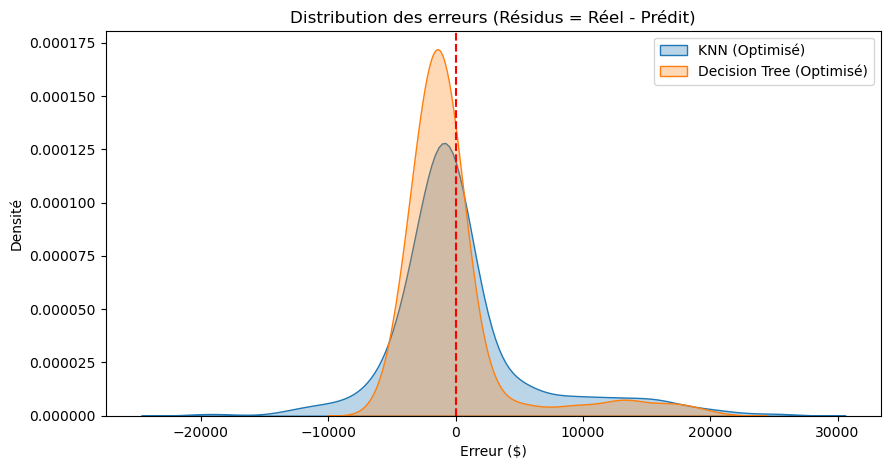

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals_knn = Y_test - y_pred_knn_opt
residuals_dt = Y_test - y_pred_dt_opt

plt.figure(figsize=(10, 5))
sns.kdeplot(residuals_knn, label='KNN (Optimisé)', fill=True, alpha=0.3)
sns.kdeplot(residuals_dt, label='Decision Tree (Optimisé)', fill=True, alpha=0.3)

plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des erreurs (Résidus = Réel - Prédit)")
plt.xlabel("Erreur ($)")
plt.ylabel("Densité")
plt.legend()
plt.show()


### Commentaire (résidus)
- Les deux distributions sont centrées près de 0, avec un pic légèrement à gauche : pour la majorité des clients, les modèles **surestiment un peu** les frais (de l'ordre de 1 000 $).

## 8.2 Comparaison côte à côte (Réel vs Prédit)


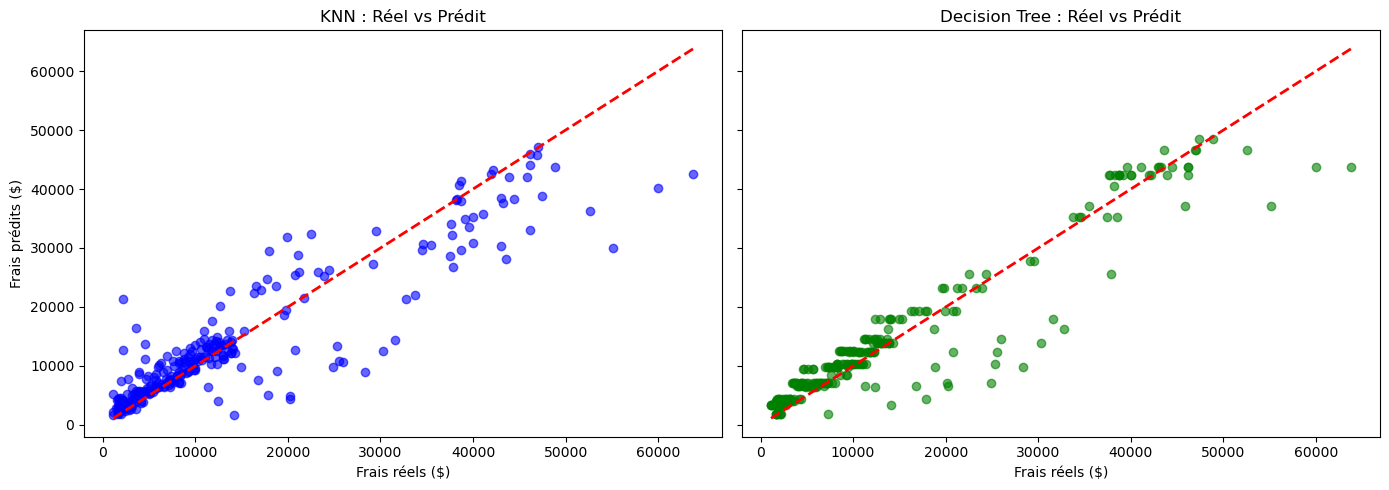

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# KNN
axes[0].scatter(Y_test, y_pred_knn_opt, alpha=0.6, color='blue')
axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
axes[0].set_title("KNN : Réel vs Prédit")
axes[0].set_xlabel("Frais réels ($)")
axes[0].set_ylabel("Frais prédits ($)")

# Decision Tree
axes[1].scatter(Y_test, y_pred_dt_opt, alpha=0.6, color='green')
axes[1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
axes[1].set_title("Decision Tree : Réel vs Prédit")
axes[1].set_xlabel("Frais réels ($)")

plt.tight_layout()
plt.show()


### Commentaire (Réel vs Prédit)
- KNN (bleu) : les points sont plus éparpillés autour de la ligne, surtout au milieu (20 000-40 000 $). Le modèle se trompe plus souvent, dans les deux sens.
- l'arbre classe les clients dans des groupes et donne le même prix à tous les clients d'un même groupe.

# 9. Comparaison finale des modèles et choix du modèle optimal (Zohair & Brice)

## 9.1 Tableau comparatif

In [30]:
from sklearn.model_selection import cross_val_score

def evaluer(nom, modele, y_pred):
    """Calcule toutes les métriques d'un modèle déjà entraîné."""
    cv = cross_val_score(modele, X_train_scaled, Y_train, cv=5, scoring='r2')
    return {
        'Modèle': nom,
        'MAE ($)': metrics.mean_absolute_error(Y_test, y_pred),
        'MSE': metrics.mean_squared_error(Y_test, y_pred),
        'RMSE ($)': np.sqrt(metrics.mean_squared_error(Y_test, y_pred)),
        'R² test': metrics.r2_score(Y_test, y_pred),
        'R² train': metrics.r2_score(Y_train, modele.predict(X_train_scaled)),
        'R² CV (moyenne)': cv.mean(),
    }

# Les 5 versions demandées
resultats = pd.DataFrame([
    evaluer('Régression Linéaire', lr, Y_pred_lr),
    evaluer('KNN', knn, y_pred_knn),
    evaluer('Arbre de Décision', dt, y_pred_dt),
    evaluer('Random Forest', rf, Y_pred_rf),
    evaluer('Random Forest optimisé', rf_optimise, y_pred_rf_optimise),
]).set_index('Modèle')

resultats.style.format({
    'MAE ($)': '{:,.0f}', 'MSE': '{:,.0f}', 'RMSE ($)': '{:,.0f}',
    'R² test': '{:.3f}', 'R² train': '{:.3f}', 'R² CV (moyenne)': '{:.3f}'
}).highlight_max(subset=['R² test', 'R² CV (moyenne)'], color='lightgreen') \
  .highlight_min(subset=['MAE ($)', 'MSE', 'RMSE ($)'], color='lightgreen')

,MAE ($),MSE,RMSE ($),R² test,R² train,R² CV (moyenne)
Modèle,,,,,,
Régression Linéaire,"4,177","35,481,472","5,957",0.807,0.730,0.726
KNN,"3,470","29,897,937","5,468",0.837,0.850,0.761
Arbre de Décision,"2,917","38,918,076","6,238",0.788,1.000,0.667
Random Forest,"2,665","22,227,850","4,715",0.879,0.974,0.820
Random Forest optimisé,"2,440","18,137,957","4,259",0.901,0.879,0.843


## 9.2 Complément : versions optimisées de KNN et de l'Arbre de Décision
Pour être complet, on compare aussi les versions optimisées par GridSearchCV de KNN et de l'Arbre de Décision à notre meilleur modèle.

In [31]:
complement = pd.DataFrame([
    evaluer('KNN optimisé', grid_knn.best_estimator_, y_pred_knn_opt),
    evaluer('Arbre de Décision optimisé', grid_dt.best_estimator_, y_pred_dt_opt),
    evaluer('Random Forest optimisé', rf_optimise, y_pred_rf_optimise),
]).set_index('Modèle')

complement.style.format({
    'MAE ($)': '{:,.0f}', 'MSE': '{:,.0f}', 'RMSE ($)': '{:,.0f}',
    'R² test': '{:.3f}', 'R² train': '{:.3f}', 'R² CV (moyenne)': '{:.3f}'
})

,MAE ($),MSE,RMSE ($),R² test,R² train,R² CV (moyenne)
Modèle,,,,,,
KNN optimisé,"3,456","32,225,016","5,677",0.825,1.000,0.776
Arbre de Décision optimisé,"2,696","19,688,792","4,437",0.893,0.865,0.829
Random Forest optimisé,"2,440","18,137,957","4,259",0.901,0.879,0.843


## 9.3 Visualisation

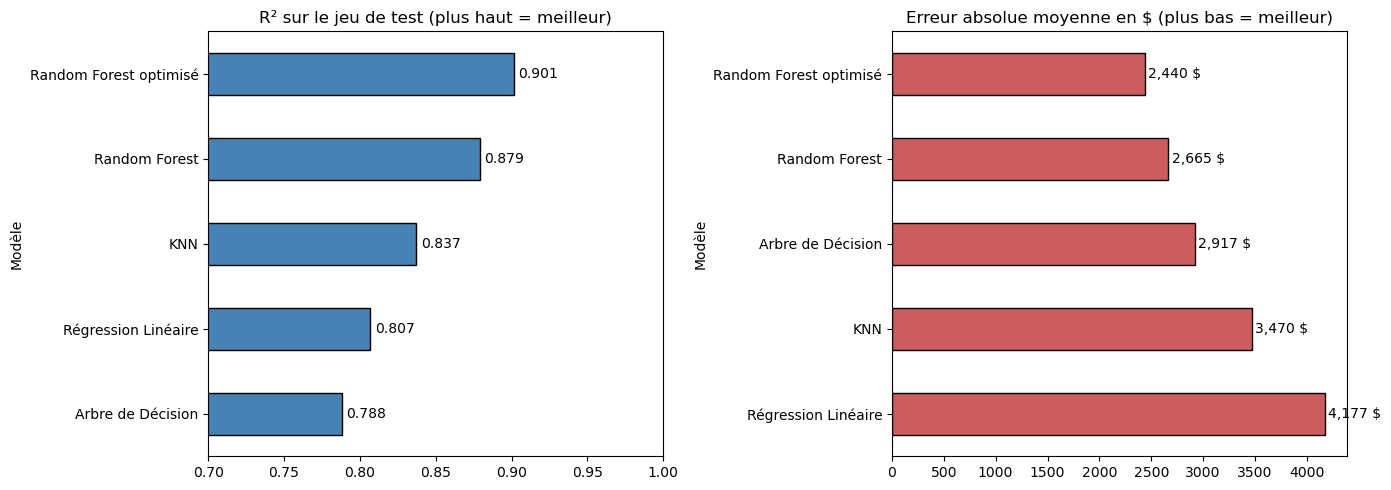

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resultats['R² test'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('R² sur le jeu de test (plus haut = meilleur)')
axes[0].set_xlim(0.7, 1)
for i, v in enumerate(resultats['R² test'].sort_values()):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center')

resultats['MAE ($)'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='indianred', edgecolor='black')
axes[1].set_title('Erreur absolue moyenne en $ (plus bas = meilleur)')
for i, v in enumerate(resultats['MAE ($)'].sort_values(ascending=False)):
    axes[1].text(v + 30, i, f'{v:,.0f} $', va='center')

plt.tight_layout()
plt.show()

## 9.4 Choix du modèle optimal

**Modèle retenu : Random Forest optimisé** (`n_estimators=200`, `max_depth=5`).

Justification :
1. **Meilleure performance** sur toutes les métriques du test.
2. **Pas de surapprentissage** 

## 9.5 Importance des variables (Random Forest optimisé)

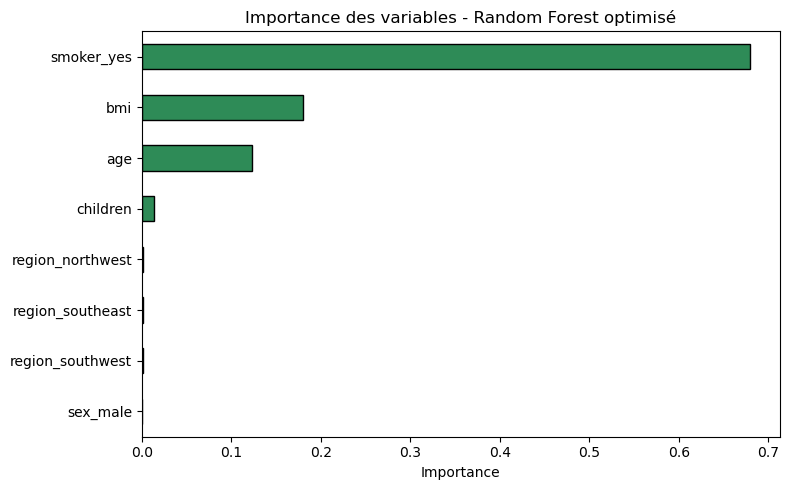

smoker_yes          0.679
bmi                 0.180
age                 0.123
children            0.014
region_northwest    0.001
region_southeast    0.001
region_southwest    0.001
sex_male            0.001
dtype: float64

In [33]:
importances = pd.Series(rf_optimise.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='seagreen', edgecolor='black')
plt.title("Importance des variables - Random Forest optimisé")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).round(3)

### Commentaire
- **smoker_yes** explique à lui seul environ **68 %** des décisions du modèle, ce qui confirme l'EDA (corrélation de 0.79 avec les frais).
- Viennent ensuite l'**IMC**.
- Le sexe, la région et le nombre d'enfants ont une importance quasi nulle.
- Message métier pour Aegis : la tarification repose essentiellement sur trois facteurs de risque, **tabagisme, IMC et âge**. Le sexe n'influence pas les frais prédits, ce qui est aussi un point positif en matière de non-discrimination tarifaire.

# 10. Export du modèle pour le Dashboard Streamlit

In [34]:
import joblib
import sklearn

artefacts = {
    'modele': rf_optimise,
    'scaler': scaler,
    'colonnes': X.columns.tolist(),
    'version_sklearn': sklearn.__version__,
}
joblib.dump(artefacts, 'modele_aegis.joblib')
print("Modèle sauvegardé : modele_aegis.joblib")
print("Version scikit-learn :", sklearn.__version__, "(à reporter dans requirements.txt)")

Modèle sauvegardé : modele_aegis.joblib
Version scikit-learn : 1.7.2 (à reporter dans requirements.txt)


In [35]:
# Test de rechargement + fonction de prédiction réutilisable dans Streamlit
def predire_frais(age, sex, bmi, children, smoker, region, chemin='modele_aegis.joblib'):
    """Prédit les frais médicaux annuels d'un client à partir de ses caractéristiques brutes."""
    a = joblib.load(chemin)
    client = pd.DataFrame([{
        'age': age,
        'bmi': bmi,
        'children': children,
        'sex_male': sex == 'male',
        'smoker_yes': smoker == 'yes',
        'region_northwest': region == 'northwest',
        'region_southeast': region == 'southeast',
        'region_southwest': region == 'southwest',
    }])[a['colonnes']]
    return a['modele'].predict(a['scaler'].transform(client))[0]

# Exemples : même profil, fumeur vs non-fumeur
print(f"Homme 45 ans, IMC 32, 2 enfants, non-fumeur : {predire_frais(45, 'male', 32, 2, 'no', 'southeast'):,.0f} $")
print(f"Homme 45 ans, IMC 32, 2 enfants, fumeur     : {predire_frais(45, 'male', 32, 2, 'yes', 'southeast'):,.0f} $")

Homme 45 ans, IMC 32, 2 enfants, non-fumeur : 9,044 $
Homme 45 ans, IMC 32, 2 enfants, fumeur     : 42,917 $
